# Proyecto: Modelos Bayesianos para Datos de Conteo

## Objetivo general

El objetivo de este proyecto es construir, ajustar y comparar modelos bayesianos para datos de conteo utilizando datos reales.

Los estudiantes deberán implementar:

- regresión Poisson,
- regresión Binomial Negativa,

y comparar su capacidad predictiva y su adecuación estadística.

El proyecto busca integrar:

- modelos lineales generalizados,
- inferencia bayesiana,
- regularización,
- métodos MCMC,
- y análisis de sobre-dispersión.

---

# Notación

- $y_i$ representa una variable de conteo.
- $x_i$ es el vector de covariables.
- $\beta$ representa los coeficientes de regresión.
- $\mu_i$ representa la media condicional.
- $\tau$ es el hyperparámetro de regularización.
- $\alpha$ representa el parámetro de dispersión.
- $X$ representa la matriz de diseño.
- $n$ es el número de observaciones.
- $p$ es el número de covariables.

---

# 1. Datos de conteo

Los modelos de conteo se utilizan cuando:

$$
y_i \in \{0,1,2,\dots\}
$$

representa:

- número de eventos,
- frecuencia de ocurrencias,
- conteos observados.

Ejemplos:

- número de accidentes,
- visitas hospitalarias,
- llamadas telefónicas,
- reclamaciones de seguros,
- incidencias de enfermedades.

---

# 2. Regresión Poisson

La regresión Poisson asume:

$$
y_i
\sim
\text{Poisson}(\mu_i)
$$

donde:

$$
\mu_i
=
\exp(x_i^T\beta)
$$

La función exponencial garantiza:

$$
\mu_i > 0
$$

---

# 3. Link logarítmico

El modelo Poisson utiliza el enlace logarítmico:

$$
\log(\mu_i)
=
x_i^T\beta
$$

Esto convierte el modelo en un modelo lineal sobre la escala logarítmica.

---

# 4. Offsets

En algunos problemas existe exposición variable entre observaciones.

En esos casos se utiliza un offset:

$$
\log(\mu_i)
=
\log(\text{offset}_i)
+
x_i^T\beta
$$

El offset permite modelar tasas en lugar de conteos absolutos.

Ejemplos:

- accidentes por kilómetro,
- casos por población,
- eventos por unidad de tiempo.

---

# 5. Priors Bayesianos

Los coeficientes utilizan priors Gaussianos:

$$
\beta_j
\sim
\mathcal{N}(0,\tau^2)
$$

con:

$$
\tau
\sim
\text{HalfNormal}(10)
$$

Esto induce regularización sobre los coeficientes y ayuda a controlar sobreajuste.

---

# 6. Problema de sobre-dispersión

El modelo Poisson asume:

$$
\mathbb{E}[Y_i]
=
\text{Var}(Y_i)
$$

Sin embargo, en muchos datasets reales:

$$
\text{Var}(Y_i)
>
\mathbb{E}[Y_i]
$$

Este fenómeno se conoce como sobre-dispersión.

Cuando existe sobre-dispersión, el modelo Poisson puede:

- subestimar incertidumbre,
- producir ajuste deficiente,
- generar predicciones poco realistas.

---

# 7. Regresión Binomial Negativa

La regresión Binomial Negativa generaliza el modelo Poisson introduciendo un parámetro de dispersión:

$$
y_i
\sim
\text{NegativeBinomial}(\mu_i,\alpha)
$$

donde:

- $\mu_i$ controla la media,
- $\alpha$ controla la dispersión adicional.

---

# 8. Parámetro de dispersión

El parámetro:

$$
\alpha
\sim
\text{HalfNormal}(10)
$$

permite capturar variabilidad extra en los datos.

Interpretación:

- $\alpha$ pequeño:
  - comportamiento cercano a Poisson.

- $\alpha$ grande:
  - mayor sobre-dispersión.

---

# 9. Inferencia Bayesiana

El objetivo es aproximar la distribución posterior:

$$
p(\beta,\tau,\alpha \mid X,y)
$$

utilizando:

- Markov Chain Monte Carlo (MCMC),
- Hamiltonian Monte Carlo (HMC),
- No-U-Turn Sampler (NUTS).

El resultado final consiste en muestras posteriores de los parámetros y distribuciones predictivas.

---

# 10. Validación Cruzada

La comparación entre modelos se realizará mediante validación cruzada.

En cada fold:

1. se ajusta el modelo,
2. se generan muestras posteriores,
3. se evalúa desempeño fuera de muestra.

---

# 11. Métrica de evaluación

La métrica principal será el Negative Log-Likelihood (NLL):

$$
\text{NLL}
=
-\log p(y_{\text{valid}} \mid X_{\text{valid}})
$$

Interpretación:

- menor NLL:
  - mejor capacidad predictiva,
  - mejor calibración probabilística.

- mayor NLL:
  - peor desempeño predictivo.

---

# 12. Visualización y análisis posterior

Los estudiantes deberán analizar:

- distribuciones posteriores de coeficientes,
- incertidumbre posterior,
- comportamiento de $\alpha$,
- estabilidad de parámetros,
- ajuste predictivo,
- evidencia de sobre-dispersión.

También deberán visualizar:

- densidades posteriores,
- distribuciones predictivas,
- comparaciones entre modelos.

---

# 13. Objetivos específicos del proyecto

Los estudiantes deberán:

1. Seleccionar un dataset real de conteos.
2. Realizar limpieza y preprocesamiento.
3. Implementar regresión Poisson bayesiana.
4. Implementar regresión Binomial Negativa bayesiana.
5. Ajustar modelos mediante NUTS.
6. Analizar convergencia MCMC.
7. Detectar sobre-dispersión.
8. Comparar desempeño predictivo.
9. Interpretar parámetros y efectos.
10. Elaborar conclusiones estadísticas.

---

# 14. Entregables sugeridos

El proyecto deberá incluir:

- notebook reproducible,
- explicación teórica,
- análisis exploratorio,
- implementación de modelos,
- métricas de evaluación,
- visualizaciones posteriores,
- interpretación estadística,
- conclusiones.

In [ ]:
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, log_likelihood
import jax.random as random
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, ParameterSampler, KFold
from scipy.stats import distributions as scdist
import numpyro
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

numpyro.set_host_device_count(3)
plt.style.use("tableau-colorblind10")

# **Conjunto de datos**

En el proyecto pueden usar datos simulados para ilustrar, pero también utilicen datos reales para resolver un problema de aprendizaje no supervisado. Realicen el debido preprocesamiento de datos que han aprendido en sus demás cursos antes de ajustar los modelos: escaladores, métodos de reducción de dimensión con PCA, entre otros.

In [53]:
n = 5000

p = 5

seed = 1808

X = np.random.rand(n, p)
X = np.hstack((np.ones((n, 1)),X))

beta = np.array([1.5, -0.01, 0.25, 0.0, 2.1, 1.4])

rates = jnp.exp(X @ beta)
alpha = 2.1

y = dist.NegativeBinomial2(rates, alpha).sample(random.PRNGKey(seed))

y = jnp.clip(y, 0, 50)

X = jnp.array(X)
y = jnp.array(y)


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=18081997)

(array([ 440.,  632.,  563.,  530.,  415.,  371.,  265.,  221.,  200.,
        1363.]),
 array([ 0.,  5., 10., 15., 20., 25., 30., 35., 40., 45., 50.]),
 <BarContainer object of 10 artists>)

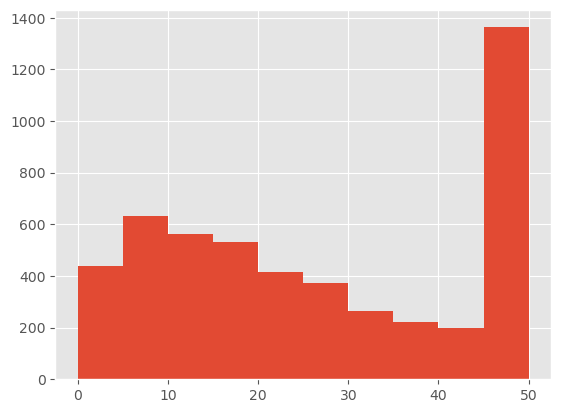

In [54]:
plt.hist(y)

# **Regresión Poisson**

In [6]:
def poisson_regression(X, y=None, offset=None):



    n, p = X.shape

    tau = numpyro.sample("tau", dist.HalfNormal(10.0))

    beta = numpyro.sample(
            "beta",
            dist.Normal(0.0, tau).expand([p]).to_event(1)
        )
    if offset is  None:

        mu = jnp.exp(jnp.matmul(X, beta))

    else:
        mu = jnp.exp(jnp.log(offset) + jnp.matmul(X, beta))


    with numpyro.plate("data", n):

            numpyro.sample(
                "y",
                dist.Poisson(mu),
                obs=y
            )

In [7]:
burn_in = 1500
num_samples = 2000
num_chains = 3
chain_method = "parallel"

seed = 18081997

In [10]:
def cv_nll_model(model, X, y, offset=None, folds=10, seed=1):

    kf = KFold(n_splits=folds, shuffle=True, random_state=seed)

    fold_nll = []

    progress_bar = tqdm(total=folds, desc="Cross Validation")

    for fold, (train_indx, valid_indx) in enumerate(kf.split(X)):

        X_train, X_valid = X[train_indx], X[valid_indx]
        y_train, y_valid = y[train_indx], y[valid_indx]

        rng_key = random.PRNGKey(seed + fold)

        kernel = NUTS(model)

        mcmc = MCMC(kernel,
                        num_samples=num_samples,
                        num_chains=num_chains,
                        num_warmup=burn_in,
                        chain_method=chain_method,
                        progress_bar=False)

        mcmc.run(rng_key, X_train, y_train, offset)

        posterior_samples = mcmc.get_samples()

        nll = -log_likelihood(model, posterior_samples, X_valid, y_valid, offset)["y"].mean(axis=1).mean().item()

        fold_nll.append(nll)

        progress_bar.update(1)
        progress_bar.set_postfix({
            "fold": fold,
            "nll": f"{nll:.4f}"
            })


    progress_bar.close()

    return fold_nll

In [11]:
results_nll = cv_nll_model(poisson_regression, X_train, y_train)

Cross Validation: 100%|██████████| 10/10 [00:59<00:00,  5.97s/it, fold=9, nll=83.4757]


In [12]:
print("mean nll:", np.mean(results_nll))
print("std nll:", np.std(results_nll))

mean nll: 59.05274505615235
std nll: 16.4234845851221


In [13]:
def neg_binom_regression(X, y=None, offset=None):

    n, p = X.shape

    tau = numpyro.sample("tau", dist.HalfNormal(10.0))

    alpha = numpyro.sample("alpha", dist.HalfNormal(10.0))

    beta = numpyro.sample(
            "beta",
            dist.Normal(0.0, tau).expand([p]).to_event(1)
        )

    if offset is  None:

        mu = jnp.exp(jnp.matmul(X, beta))

    else:
        mu = jnp.exp(jnp.log(offset) + jnp.matmul(X, beta))


    with numpyro.plate("data", n):

            numpyro.sample(
                "y",
                dist.NegativeBinomial2(mu, alpha),
                obs=y
            )

In [14]:
results_nll = cv_nll_model(neg_binom_regression, X_train, y_train)

Cross Validation: 100%|██████████| 10/10 [04:49<00:00, 28.98s/it, fold=9, nll=1.6338]


In [15]:
print("mean nll:", np.mean(results_nll))
print("std nll:", np.std(results_nll))

mean nll: 1.3871037483215332
std nll: 0.14606378744289994


# **Mejor modelo**

In [55]:
rng_key = random.PRNGKey(seed)

kernel = NUTS(neg_binom_regression)

mcmc = MCMC(kernel,
            num_samples=num_samples,
            num_chains=num_chains,
            num_warmup=burn_in,
            chain_method=chain_method,
            progress_bar=True)

mcmc.run(rng_key, X_train, y_train)

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

In [56]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     alpha      3.06      0.08      3.05      2.93      3.18   6393.20      1.00
   beta[0]      1.94      0.04      1.94      1.87      2.00   3582.20      1.00
   beta[1]     -0.02      0.03     -0.02     -0.07      0.03   5644.15      1.00
   beta[2]      0.18      0.03      0.18      0.12      0.23   5830.37      1.00
   beta[3]     -0.02      0.03     -0.02     -0.07      0.03   5583.18      1.00
   beta[4]      1.44      0.03      1.44      1.38      1.49   5507.97      1.00
   beta[5]      0.90      0.03      0.90      0.85      0.96   5470.94      1.00
       tau      1.36      0.56      1.23      0.66      2.06   3616.76      1.00

Number of divergences: 0


In [57]:
samples = mcmc.get_samples()

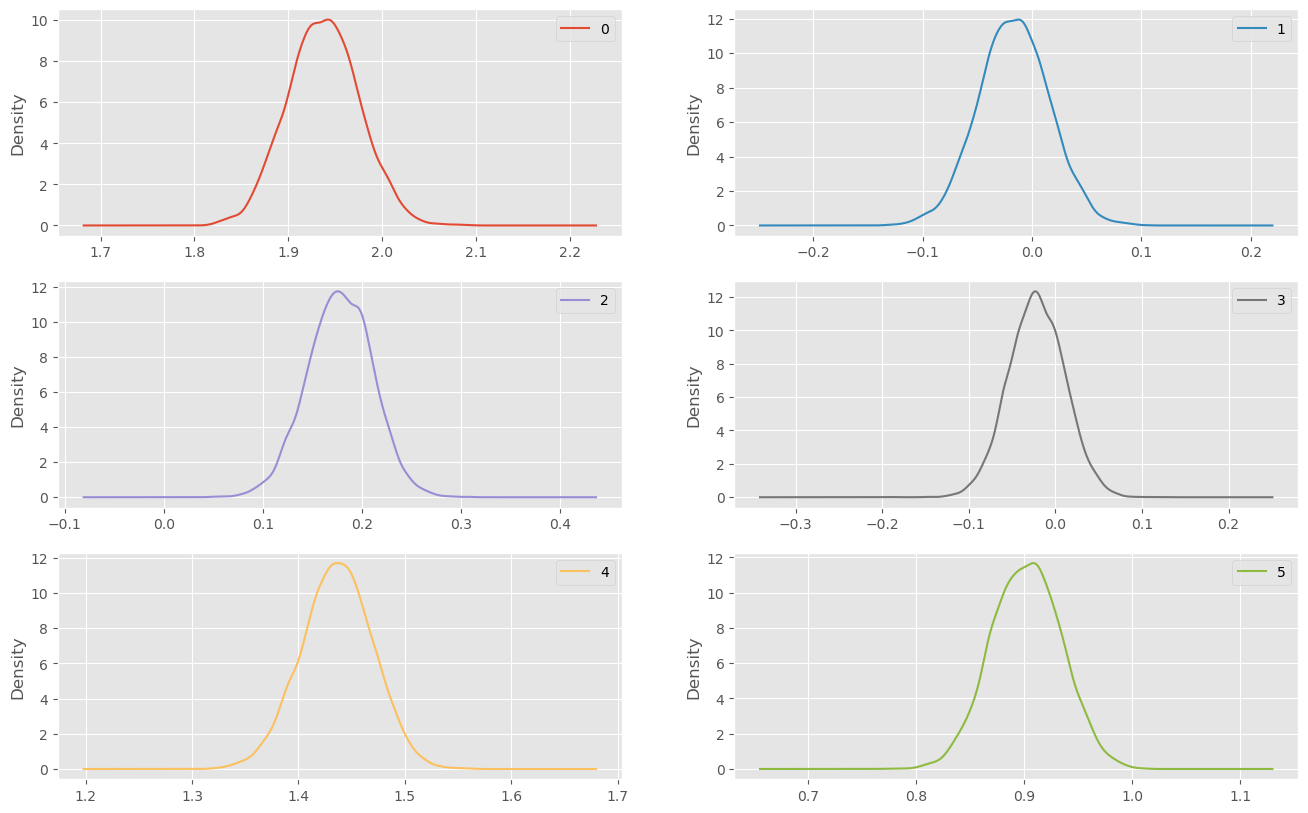

In [58]:
pd.DataFrame(samples["beta"]).plot.kde(subplots=True, layout=(3, 2), sharex=False, figsize=(16, 10))
plt.show()

In [59]:
nll_samples = -log_likelihood(neg_binom_regression, samples, X_val, y_val)["y"].mean(axis=1)

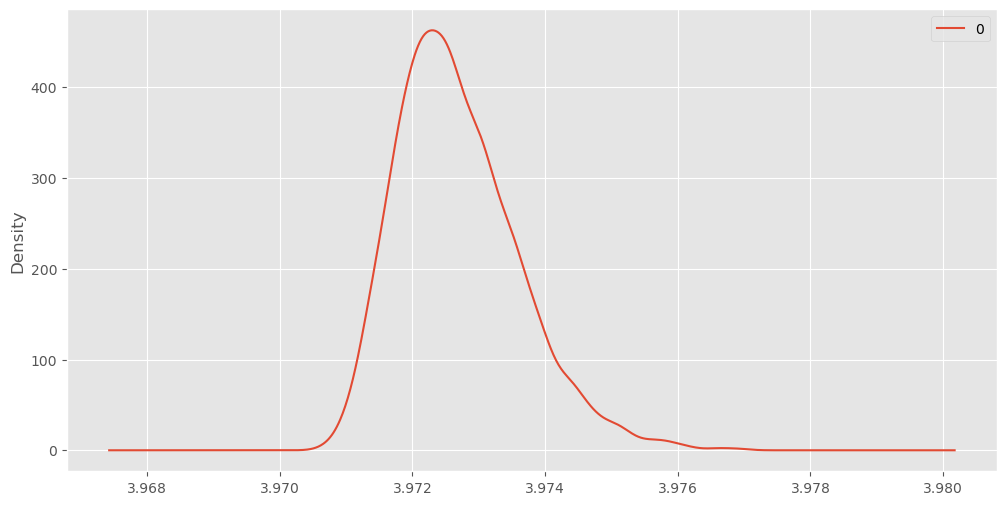

In [60]:
pd.DataFrame(nll_samples).plot.kde(figsize=(12, 6))
plt.show()

In [61]:
y_pred_samples = jnp.exp(jnp.matmul(samples["beta"], X_val.T))

y_mean = jnp.mean(y_pred_samples, axis=0)
y_low = jnp.percentile(y_pred_samples, 2.5, axis=0)
y_high = jnp.percentile(y_pred_samples, 97.5, axis=0)


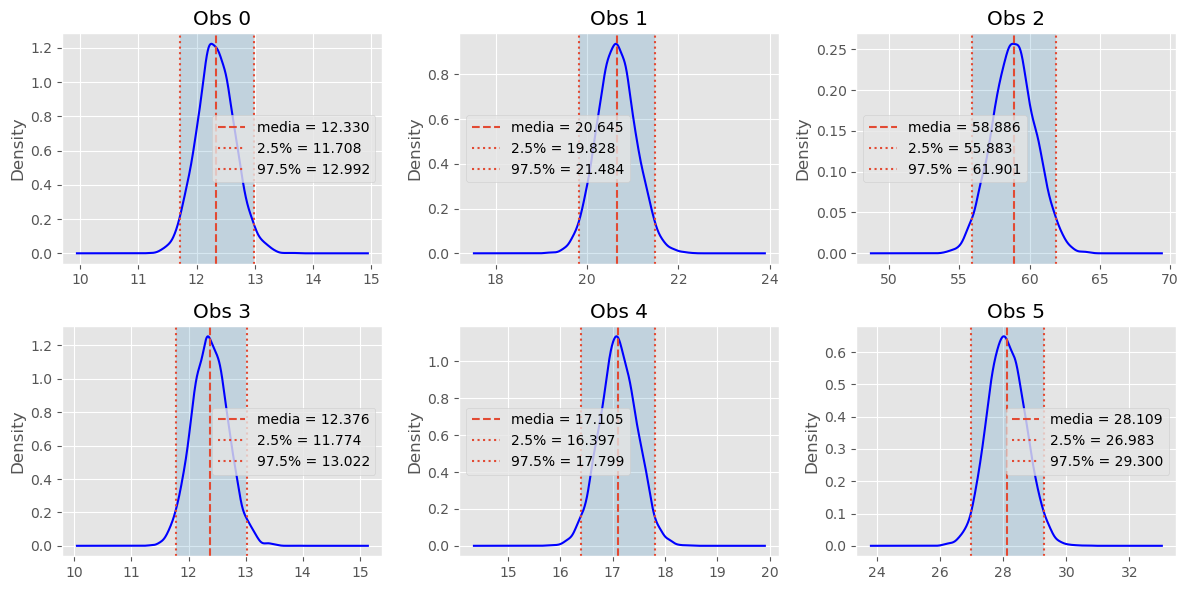

In [63]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

axes = axes.flatten()

for i, ax in enumerate(axes):

    # KDE
    pd.Series(np.array(y_pred_samples[:, i])).plot.kde(ax=ax, color="blue")

    # media
    ax.axvline(
        y_mean[i],
        linestyle="--",
        label=f"media = {y_mean[i]:.3f}"
    )

    # intervalos
    ax.axvline(
        y_low[i],
        linestyle=":",
        label=f"2.5% = {y_low[i]:.3f}"
    )

    ax.axvline(
        y_high[i],
        linestyle=":",
        label=f"97.5% = {y_high[i]:.3f}"
    )


    ax.axvspan(y_low[i], y_high[i], alpha=0.2)

    ax.set_title(f"Obs {i}")

    ax.legend()

plt.tight_layout()
plt.show()

In [32]:
y_train

Array([  0,   0,   0, ...,   1,   0, 177], dtype=int32)